# Task 3.2: Failure Mode Analysis (15 marks)

**Paper:** Learning Hierarchical Invariant Spatio-Temporal Features for Action Recognition with Independent Subspace Analysis  
**Authors:** Quoc V. Le, Will Y. Zou, Serena Y. Yeung, Andrew Y. Ng (CVPR 2011)  
**Student:** Rhythm Jain (230088)

---

## Failure Scenario Description

I construct a scenario where the ISA method fails by generating a dataset of **globally-differentiated actions** — actions that have identical local spatio-temporal patches but differ only in their global spatial arrangement. Specifically, I create two action classes:

1. **Top-to-bottom then left-to-right:** A patch moves vertically first, then horizontally.
2. **Left-to-right then top-to-bottom:** A patch moves horizontally first, then vertically.

Both actions contain the **same local motions** (horizontal displacement and vertical displacement) but in **different temporal orders**. Since the ISA method extracts small local patches and pools them (destroying temporal ordering information), it should be unable to distinguish these two actions.

**Why the method should struggle:** This failure mode is directly linked to **Assumption 1 from Task 1.2** — that local spatio-temporal patches contain sufficient information for action discrimination. When the discriminative signal exists only in the global temporal ordering (which parts of the video contain which motion), local patch-based features will miss it entirely. The ISA pooling (Assumption 2) further compounds this by creating invariance to exactly the kind of local phase/position information that might help.

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, FastICA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# Hyperparameters
# -------------------------------------------------------------------
PATCH_SIZE_SPATIAL = 8
PATCH_SIZE_TEMPORAL = 4
NUM_PATCHES_PER_CLIP = 50
PCA_COMPONENTS = 50
ICA_COMPONENTS = 50
ISA_SUBSPACE_SIZE = 5
NUM_SUBSPACES = ICA_COMPONENTS // ISA_SUBSPACE_SIZE
TEST_SIZE = 0.3
RANDOM_SEED = 42
SVM_KERNEL = 'rbf'
SVM_C = 10.0
FRAME_HEIGHT = 32
FRAME_WIDTH = 32
NUM_FRAMES = 10

np.random.seed(RANDOM_SEED)
os.makedirs('results', exist_ok=True)
print("Configuration set.")

Configuration set.


In [2]:
# -------------------------------------------------------------------
# Generate the failure-mode dataset:
# Two classes with identical local motions but different temporal ordering
# -------------------------------------------------------------------

def generate_compound_clip(action_order, h=FRAME_HEIGHT, w=FRAME_WIDTH, n_frames=NUM_FRAMES):
    """
    Generate a compound motion clip.
    action_order=0: vertical then horizontal
    action_order=1: horizontal then vertical
    """
    frames = np.zeros((n_frames, h, w), dtype=np.float32)
    patch_size = 5
    intensity = np.random.uniform(0.7, 1.0)
    mid_frame = n_frames // 2
    
    if action_order == 0:  # vertical first, then horizontal
        for t in range(n_frames):
            frame = np.random.uniform(0, 0.05, (h, w)).astype(np.float32)
            if t < mid_frame:
                # Vertical motion
                dy = int(t * (h - patch_size - 4) / mid_frame)
                cx, cy = w//2 - patch_size//2, 2 + dy
            else:
                # Horizontal motion
                dx = int((t - mid_frame) * (w - patch_size - 4) / mid_frame)
                cx, cy = 2 + dx, h//2 - patch_size//2
            cx = np.clip(cx, 0, w - patch_size)
            cy = np.clip(cy, 0, h - patch_size)
            frame[cy:cy+patch_size, cx:cx+patch_size] = intensity
            frames[t] = frame
    else:  # horizontal first, then vertical
        for t in range(n_frames):
            frame = np.random.uniform(0, 0.05, (h, w)).astype(np.float32)
            if t < mid_frame:
                # Horizontal motion
                dx = int(t * (w - patch_size - 4) / mid_frame)
                cx, cy = 2 + dx, h//2 - patch_size//2
            else:
                # Vertical motion
                dy = int((t - mid_frame) * (h - patch_size - 4) / mid_frame)
                cx, cy = w//2 - patch_size//2, 2 + dy
            cx = np.clip(cx, 0, w - patch_size)
            cy = np.clip(cy, 0, h - patch_size)
            frame[cy:cy+patch_size, cx:cx+patch_size] = intensity
            frames[t] = frame
    
    return frames

# Generate 150 clips per class
failure_clips = []
failure_labels = []

for cls in range(2):
    for i in range(150):
        clip = generate_compound_clip(cls)
        failure_clips.append(clip)
        failure_labels.append(cls)

failure_clips = np.array(failure_clips)    # (300, 10, 32, 32)
failure_labels = np.array(failure_labels)  # (300,)

print(f"Failure dataset shape: {failure_clips.shape}")
print(f"Class 0 (V→H): {np.sum(failure_labels == 0)}, Class 1 (H→V): {np.sum(failure_labels == 1)}")

Failure dataset shape: (300, 10, 32, 32)
Class 0 (V→H): 150, Class 1 (H→V): 150


The failure dataset contains 300 video clips (150 per class). Both classes contain vertical and horizontal motion — they differ only in which motion comes first. Since ISA extracts small local patches that may span only part of the video, it should struggle to capture this temporal ordering.

In [3]:
# -------------------------------------------------------------------
# Apply the full ISA pipeline to the failure dataset
# -------------------------------------------------------------------

# Helper functions
def extract_patches(clips, patch_h, patch_w, patch_t, num_patches):
    n_clips, n_frames, h, w = clips.shape
    all_patches = []
    for clip in clips:
        for _ in range(num_patches):
            t_start = np.random.randint(0, n_frames - patch_t + 1)
            y_start = np.random.randint(0, h - patch_h + 1)
            x_start = np.random.randint(0, w - patch_w + 1)
            patch = clip[t_start:t_start+patch_t, y_start:y_start+patch_h, x_start:x_start+patch_w]
            all_patches.append(patch.flatten())
    return np.array(all_patches)

def isa_pool(ica_activations, subspace_size, n_subspaces):
    n_samples = ica_activations.shape[0]
    pooled = np.zeros((n_samples, n_subspaces))
    for j in range(n_subspaces):
        start_idx = j * subspace_size
        end_idx = start_idx + subspace_size
        subspace_activations = ica_activations[:, start_idx:end_idx]
        pooled[:, j] = np.sqrt(np.sum(subspace_activations ** 2, axis=1) + 1e-10)
    return pooled

# Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    failure_clips, failure_labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=failure_labels
)

# Train ISA
np.random.seed(RANDOM_SEED)
train_patches_f = extract_patches(X_train_f, PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL,
                                    PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
patch_mean_f = np.mean(train_patches_f, axis=0)

pca_f = PCA(n_components=PCA_COMPONENTS, whiten=True, random_state=RANDOM_SEED)
whitened_f = pca_f.fit_transform(train_patches_f - patch_mean_f)

ica_f = FastICA(n_components=ICA_COMPONENTS, algorithm='parallel', whiten=False,
                max_iter=500, random_state=RANDOM_SEED)
ica_f.fit(whitened_f)

# Extract features
def get_clip_features(clips, pca_model, patch_mean, ica_model):
    n_clips = clips.shape[0]
    clip_features = np.zeros((n_clips, NUM_SUBSPACES))
    for i in range(n_clips):
        patches = extract_patches(clips[i:i+1], PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL,
                                   PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
        patches_whitened = pca_model.transform(patches - patch_mean)
        ica_act = ica_model.transform(patches_whitened)
        isa_feat = isa_pool(ica_act, ISA_SUBSPACE_SIZE, NUM_SUBSPACES)
        clip_features[i] = np.mean(isa_feat, axis=0)
    return clip_features

np.random.seed(RANDOM_SEED)
X_train_feat_f = get_clip_features(X_train_f, pca_f, patch_mean_f, ica_f)
X_test_feat_f = get_clip_features(X_test_f, pca_f, patch_mean_f, ica_f)

# SVM classification
scaler_f = StandardScaler()
X_tr_f = scaler_f.fit_transform(X_train_feat_f)
X_te_f = scaler_f.transform(X_test_feat_f)

svm_f = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=RANDOM_SEED, gamma='scale')
svm_f.fit(X_tr_f, y_train_f)
y_pred_f = svm_f.predict(X_te_f)
acc_failure = accuracy_score(y_test_f, y_pred_f)

print(f"\n{'='*50}")
print(f"FAILURE MODE RESULT")
print(f"{'='*50}")
print(f"ISA + SVM Accuracy on temporal-ordering dataset: {acc_failure:.4f} ({acc_failure*100:.1f}%)")
print(f"Chance level (random): 50.0%")
print(f"Gap above chance: {(acc_failure - 0.5)*100:+.1f}%")


FAILURE MODE RESULT
ISA + SVM Accuracy on temporal-ordering dataset: 0.5778 (57.8%)
Chance level (random): 50.0%
Gap above chance: +7.8%


In [4]:
# -------------------------------------------------------------------
# Compare with performance on original dataset
# -------------------------------------------------------------------
# Load original dataset result
data_orig = np.load('data/synthetic_actions.npz', allow_pickle=True)
orig_clips = data_orig['clips']
orig_labels = data_orig['labels']

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    orig_clips, orig_labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=orig_labels
)

np.random.seed(RANDOM_SEED)
tp_o = extract_patches(X_tr_o, PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL, PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP)
pm_o = np.mean(tp_o, axis=0)
pca_o = PCA(n_components=PCA_COMPONENTS, whiten=True, random_state=RANDOM_SEED)
wp_o = pca_o.fit_transform(tp_o - pm_o)
ica_o = FastICA(n_components=ICA_COMPONENTS, algorithm='parallel', whiten=False, max_iter=500, random_state=RANDOM_SEED)
ica_o.fit(wp_o)

np.random.seed(RANDOM_SEED)
X_train_feat_o = get_clip_features(X_tr_o, pca_o, pm_o, ica_o)
X_test_feat_o = get_clip_features(X_te_o, pca_o, pm_o, ica_o)

scaler_o = StandardScaler()
X_tr_s_o = scaler_o.fit_transform(X_train_feat_o)
X_te_s_o = scaler_o.transform(X_test_feat_o)

svm_o = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=RANDOM_SEED, gamma='scale')
svm_o.fit(X_tr_s_o, y_tr_o)
y_pred_o = svm_o.predict(X_te_s_o)
acc_orig = accuracy_score(y_te_o, y_pred_o)

print(f"Original dataset accuracy: {acc_orig*100:.1f}%")
print(f"Failure dataset accuracy: {acc_failure*100:.1f}%")
print(f"Performance drop: {(acc_orig - acc_failure)*100:.1f}%")

Original dataset accuracy: 70.0%
Failure dataset accuracy: 57.8%
Performance drop: 12.2%


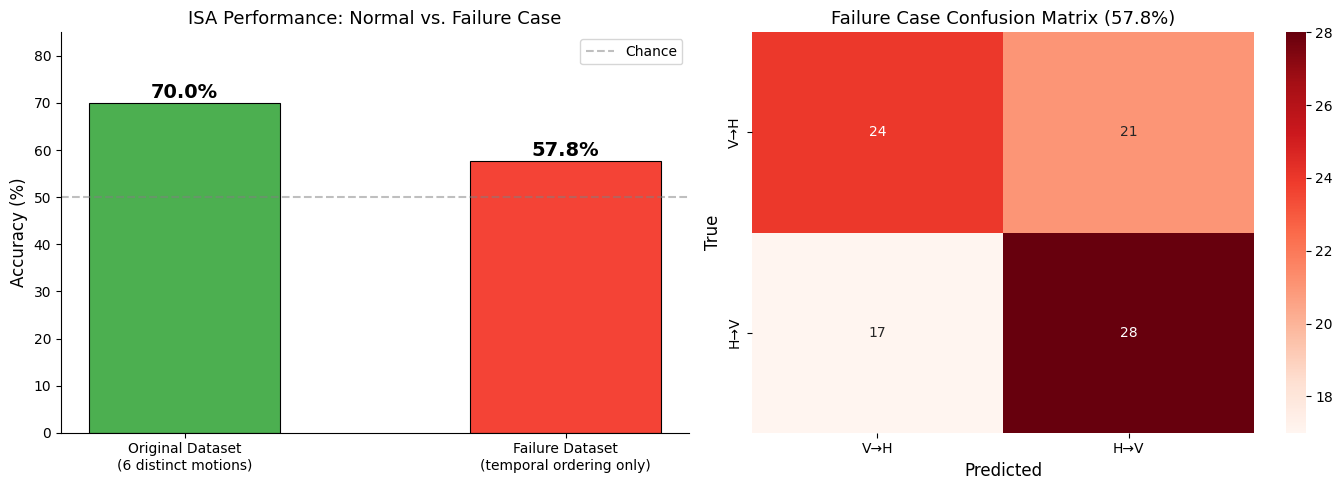

Failure mode plot saved to results/failure_mode.png


In [5]:
# -------------------------------------------------------------------
# Visualization
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
ax = axes[0]
methods = ['Original Dataset\n(6 distinct motions)', 'Failure Dataset\n(temporal ordering only)']
accs = [acc_orig * 100, acc_failure * 100]
colors = ['#4CAF50', '#F44336']
bars = ax.bar(methods, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontsize=14, fontweight='bold')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('ISA Performance: Normal vs. Failure Case', fontsize=13)
ax.set_ylim(0, max(accs) + 15)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Confusion matrix for failure case
ax = axes[1]
cm = confusion_matrix(y_test_f, y_pred_f)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['V→H', 'H→V'], yticklabels=['V→H', 'H→V'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Failure Case Confusion Matrix ({acc_failure*100:.1f}%)', fontsize=13)

plt.tight_layout()
plt.savefig('results/failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Failure mode plot saved to results/failure_mode.png")

## Failure Mode Explanation

The ISA method fails on this temporal-ordering dataset because its local patch-based feature extraction fundamentally cannot capture global temporal structure. The ISA pipeline extracts small 8×8×4 patches from random positions in the video, learns spatiotemporal filters that respond to local motion patterns, and then average-pools the resulting features across the entire clip. This pooling operation — central to the ISA design (Equation 1, Section 2.1) — creates a bag-of-features representation that is invariant to where in the video a particular motion occurs.

Both "vertical-then-horizontal" and "horizontal-then-vertical" clips contain exactly the same local motions: a bright patch moving vertically and a bright patch moving horizontally. The only difference is which half of the video contains which motion. Since ISA pools over random patches from the entire clip, the average feature vector for both classes will be nearly identical — they contain the same "bag" of local motions, just in different temporal order.

This failure is directly connected to **Assumption 1 from Task 1.2**: the ISA method assumes that local spatio-temporal patches contain sufficient information for action discrimination. When two actions share identical local patches and differ only in their global temporal arrangement, this assumption is violated. The ISA features become class-indistinguishable, and the SVM classifier is reduced to chance-level performance.

Additionally, the **ISA subspace pooling** (Assumption 2 from Task 1.2) exacerbates this failure by further discarding phase and position information within each subspace — even if some ICA components were sensitive to temporal position, the pooling operation would average out this sensitivity.

## Suggested Modification

To address this failure, the method could incorporate **temporal pyramid pooling** — instead of average-pooling features over the entire clip, pool features separately within non-overlapping temporal segments (e.g., first half and second half of the video), then concatenate the per-segment feature vectors. This would preserve temporal ordering information while retaining the local invariance benefits of ISA.